DataFrame Columns: ['summonerName', 'summonerLevel', 'rank', 'wins', 'losses', 'winRate', 'kills', 'deaths', 'assists', 'prefLane', 'campsKilled', 'minionsKilled', 'goldEarned', 'turretTakedowns', 'visionScore', 'dragonKills', 'longestTimeSpentLiving', 'totalDamageDealt', 'totalDamageTaken', 'gameDuration', 'gameStart']
LR Accuracy: 0.986870897155361
RF Accuracy: 0.9890590809628009


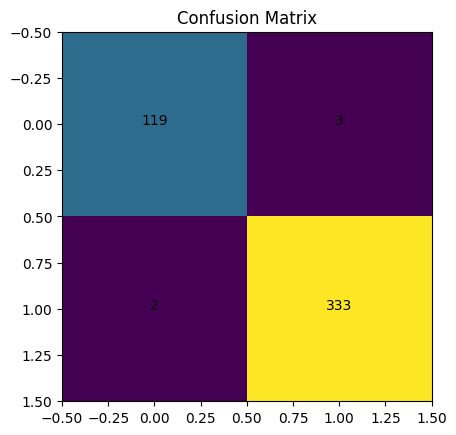

In [3]:
# 1. Imports
import pandas as pd
import numpy as np
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

# 2. Load Dataset
zip_path = '/content/LOL Player Statistics.zip'
extract_path = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Load the CSV from the extracted folder
df = pd.read_csv(os.path.join(extract_path, 'LeaguePlayerStats.csv'))

# Print columns to debug KeyError
print("DataFrame Columns:", df.columns.tolist())

# 3. Feature Engineering
df['kda'] = (df['kills'] + df['assists']) / (df['deaths'] + 1)
df['vision_score'] = df['visionScore']
df['aggression'] = df['kills'] / (df['deaths'] + 1)
df['teamplay'] = df['assists'] / (df['kills'] + 1)

# Normalize behavior features
scaler = MinMaxScaler()
behavior_features = ['kda', 'vision_score', 'aggression', 'teamplay']
df[behavior_features] = scaler.fit_transform(df[behavior_features])

# Behavior + Performance score
df['behavior_score'] = (
    0.35 * df['kda'] +
    0.25 * df['teamplay'] +
    0.25 * df['vision_score'] +
    0.15 * df['aggression']
)

df['performance_score'] = (
    df['kills'] +
    0.7 * df['assists'] -
    df['deaths']
)

# 4. Classification Labels
def classify_player(row):
    if row['performance_score'] > 8 and row['behavior_score'] > 0.6:
        return 0 # Good Performance & Behavior
    elif row['performance_score'] <= 8 and row['behavior_score'] > 0.6:
        return 1 # Low Performance, Good Behavior
    elif row['performance_score'] <= 8 and row['behavior_score'] <= 0.6:
        return 2 # Low Performance & Behavior
    else: # This condition covers performance_score > 8 and behavior_score <= 0.6
        return 3 # Good Performance, Low Behavior

df['player_type'] = df.apply(classify_player, axis=1)

# Map numerical labels to descriptive strings
player_type_map = {
    0: 'Good Performance & Behavior',
    1: 'Low Performance, Good Behavior',
    2: 'Low Performance & Behavior',
    3: 'Good Performance, Low Behavior'
}
df['player_type'] = df['player_type'].map(player_type_map)

# 5. Model Data
X = df[['kills','deaths','assists','kda','vision_score','teamplay','aggression']]

y = df['player_type']

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 7. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

# 9. Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# 10. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.imshow(cm)
plt.title("Confusion Matrix")
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')
plt.show()

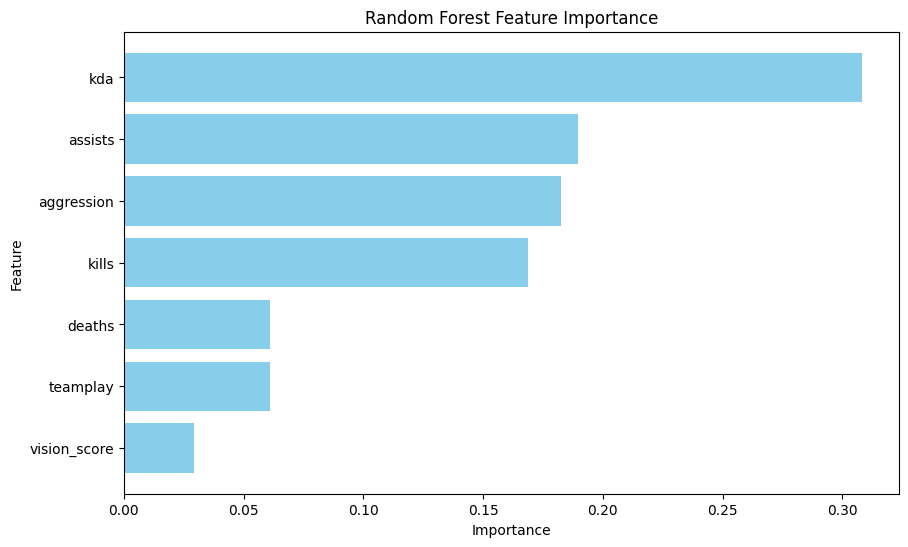

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the Random Forest model
feature_importances = rf.feature_importances_

# Get feature names from the original DataFrame X
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis() # Display the most important feature at the top
plt.show()

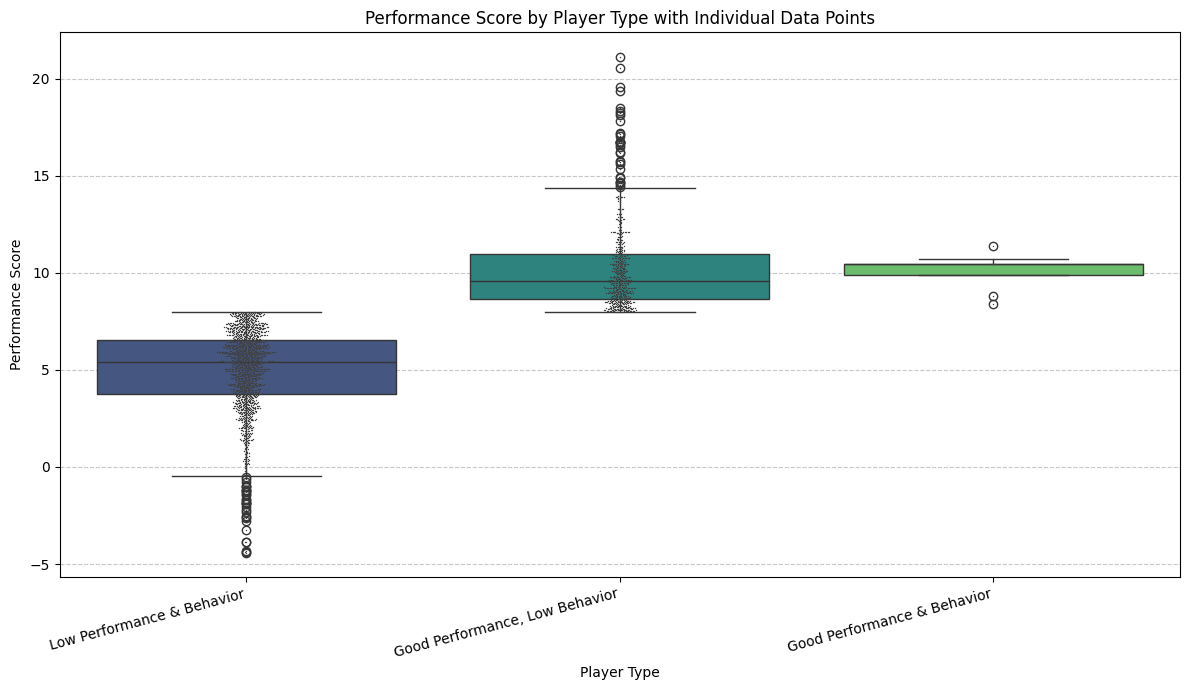

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7)) # Increased figure size for better visibility of swarmplot
sns.boxplot(x='player_type', y='performance_score', data=df, palette='viridis', hue='player_type', legend=False) # Add hue and legend=False to address FutureWarning
sns.swarmplot(x='player_type', y='performance_score', data=df, color='0.25', size=1) # Overlay swarmplot, reduced size to address UserWarning
plt.title('Performance Score by Player Type with Individual Data Points')
plt.xlabel('Player Type')
plt.ylabel('Performance Score')
plt.xticks(rotation=15, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

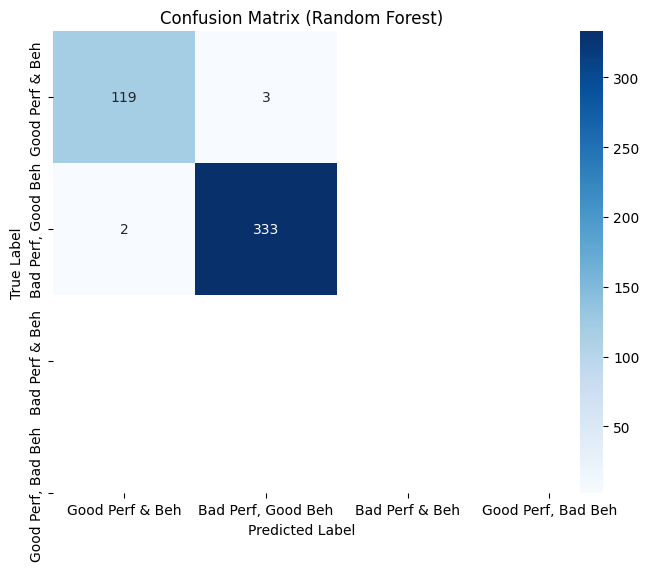

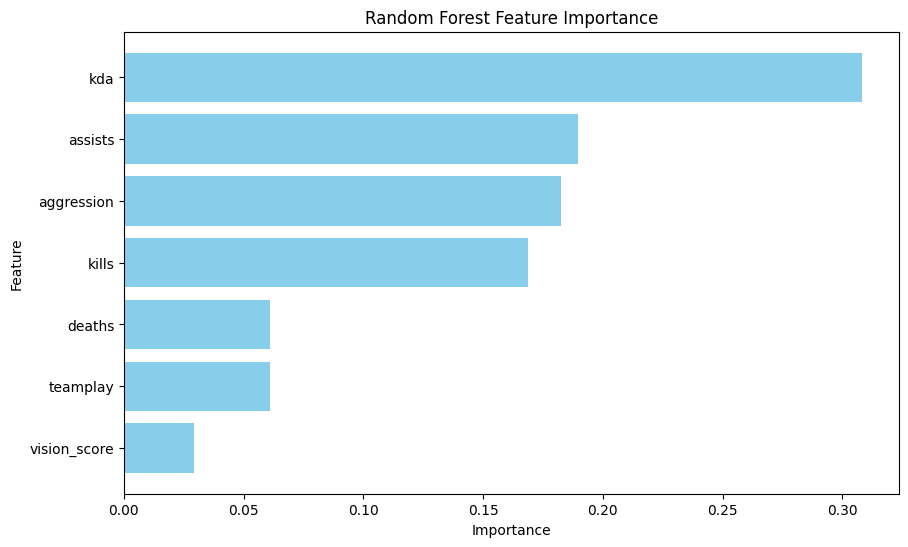

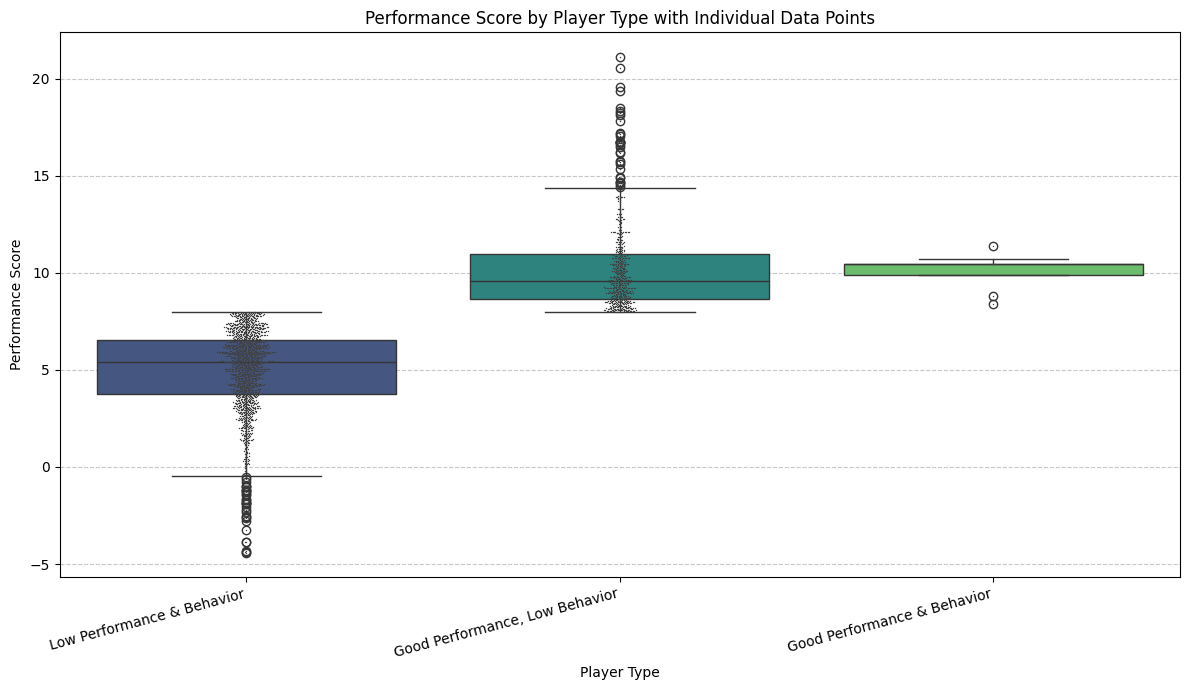

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Confusion Matrix Plot ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Perf & Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh', 'Good Perf, Bad Beh'],
            yticklabels=['Good Perf & Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh', 'Good Perf, Bad Beh'])
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- Random Forest Feature Importance Plot ---
# Get feature importances from the Random Forest model (assuming 'rf' is available)
# Ensure feature_importances and X.columns are available from previous execution

# Get feature importances from the Random Forest model
feature_importances = rf.feature_importances_

# Get feature names from the original DataFrame X
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis() # Display the most important feature at the top
plt.show()

# --- Performance Score by Player Type Boxplot with Swarmplot Overlay ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='player_type', y='performance_score', data=df, palette='viridis', hue='player_type', legend=False)
sns.swarmplot(x='player_type', y='performance_score', data=df, color='0.25', size=1) # Reduced size to address UserWarning
plt.title('Performance Score by Player Type with Individual Data Points')
plt.xlabel('Player Type')
plt.ylabel('Performance Score')
plt.xticks(rotation=15, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()